<a href="https://colab.research.google.com/github/stanislawWojtas/Przetwarzanie-Obraz-w-Cyfrowych/blob/main/09_Canny.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detekcja krawędzi

## Cel ćwiczenia

- Zapoznanie z metodami detekcji krawędzi:
    - Sobel, Prewitt, Roberts - przypomnienie,
    - Laplasjan z Gaussa (LoG – ang. Laplacian of Gaussian),
    - Canny.

Detekcja krawędzi przez wiele lat była podstawą algorytmów segmentacji.
Krawędzie wykrywane są najczęściej z wykorzystaniem pierwszej (gradient) i drugiej (Laplasjan) pochodnej przestrzennej.
Wykorzystanie obu metod zaprezentowane zostało w ćwiczeniu *Przetwarzanie wstępne. Filtracja kontekstowa*.

W niniejszym ćwiczeniu poznane detektory krawędzi zostaną porównane z bardziej zaawansowanymi: Laplasjan z funkcji Gaussa (LoG), Zero Crossing i Canny.

## Laplasjan z Gaussa (LoG)

Funkcja Gaussa:<br>
\begin{equation}
h(r) = e^{\frac{-r^2}{2 \sigma^2}}
\end{equation}<br>
gdzie:
- $r^2 = x^2 + y^2$
- $\sigma$ to odchylenie standardowe.

Działanie filtracji Gaussowskiej zostało przedstawione w ćwiczeniu "Przetwarzanie wstępne". W jej wyniku następuje rozmazanie obrazu.
Laplasjan tej funkcji dany jest wzorem:

\begin{equation}
\nabla^2 h(r) = \frac{r^2 - 2\sigma^2}{\sigma^4} e^{-\frac{r^2}{2\sigma^2}}
\end{equation}

Funkcję (z oczywistych powodów) nazywamy Laplasjan z Gaussa (LoG).
Ponieważ druga pochodna jest operacją liniową, konwolucja obrazu z $\nabla^2 h(r)$ daje taki sam efekt jak zastosowanie filtracji Gaussa na obrazie, a następnie obliczenie Laplasjanu z wyniku.
Lokalizacja krawędzi polega na znalezieniu miejsca, gdzie po filtracji LoG następuje zmiana znaku.

1. Wczytaj obraz *house.png*.
2. Wykonaj rozmycie Gaussowskie obrazu wejściowego.
W tym celu wykorzysaj funkcję `cv2.GaussianBlur(img, kSize, sigma)`.
Pierwszy argument jest obrazem wejśćiowym.
Drugi jest rozmiarem filtru (podanym w nawiasach okrągłych, np. *(3, 3)*).
Trzecim argumentem jest odchylenie standardowe. Wartość jest dobrana automatycznie, jeśli zosanie podana wartość `0` (będą równe rozmiarowi).
3. Oblicz laplasjan obrazu rozmytego.
W tym celu wykorzysaj funkcję `cv2.Laplacian(img, ddepth)`.
Pierszym argumentem jest obraz wejściowy.
Drugim argumentem jest typ danych wejściowych. Użyj `cv2.CV_32F`.
4. Wyznacz miejsca zmiany znaku.
Zaimplementuj funkcję `crossing(LoG, thr)`:
    - Najpierw stwórz tablicę, do której zostanie zapisany wynik.
    Jej rozmiar jest taki sam jak przetwarzanego obrazu.
    - Następnie wykonaj pętle po obrazie (bez ramki jednopikselowej).
    W każdej iteracji stwórz otoczenie o rozmiarze $3 \times 3$.
    Dla otoczenia oblicz wartość maksymalną i minimalną.
    - Jeśli wartości te mają przeciwne znaki, to do danego miejsca tablicy przypisz wartość:
        - jeśli piksel wejściowy > 0, to dodaj do niego wartość bezwzględną minimum.
        - jeśli piksel wejściowy < 0, to do jego wartości bezwzględnej dodaj maksimum.
    - Zmień zakres wykonanej tablicy do $<0, 255>$.
    - Wykonaj progowanie tablicy. Próg jest argumentem wejściowym.
    - Przeskaluj dane binarne do wartości `[0, 255]`.
    - Wykonaj konwersję do typu *uint8*.
    - Wykonaj rozmycie medianowe wyniku.
    Wykorzystaj funkcję `cv2.medianBlur(img, kSize)`.
    Pierwszym argumentem jest obraz wejśćiowy, a drugim rozmiar filtra.
    - Zwróć wyznaczoną tablicę.
5. Wyświetl obraz wynikowy.
6. Dobierz parametry (rozmiar filtru Gaussa, odchylenie standardowe, próg binaryzacji) tak, by widoczne były kontury domu, ale nie dachówki.

In [1]:
import cv2
from matplotlib import pyplot as plt
import numpy as np
import math
import os
import requests

url = 'https://raw.githubusercontent.com/vision-agh/poc_sw/master/09_Canny/'

fileNames = ["dom.png"]
for fileName in fileNames:
  if not os.path.exists(fileName):
      r = requests.get(url + fileName, allow_redirects=True)
      open(fileName, 'wb').write(r.content)



In [30]:
house = cv2.imread("dom.png", cv2.IMREAD_GRAYSCALE)
house_blur = cv2.GaussianBlur(house, (5,5), 3)
laplacian = cv2.Laplacian(house_blur, cv2.CV_32F)



def crossing(LoG, thr):
  result = np.zeros_like(LoG)
  Y, X = LoG.shape
  for j in range(1, Y-1):
    for i in range(1, X-1):
      neighborhood = LoG[j-1: j+2, i-1:i+2]
      min_val = np.min(neighborhood)
      max_val = np.max(neighborhood)
      if(min_val * max_val < 0):
        if(LoG[j,i] > 0):
          result[j, i] = LoG[j, i] + np.abs(min_val)
        elif(LoG[j, i] < 0):
          result[j, i] = np.abs(LoG[j, i]) + max_val
  result_norm = cv2.normalize(result, None, 0, 255, cv2.NORM_MINMAX)

  #binaryzacja
  _, result_bin = cv2.threshold(result_norm, thr, 255, cv2.THRESH_BINARY)
  result_bin = result_bin.astype(np.uint8)
  final_img = cv2.medianBlur(result_bin, 5)

  return final_img



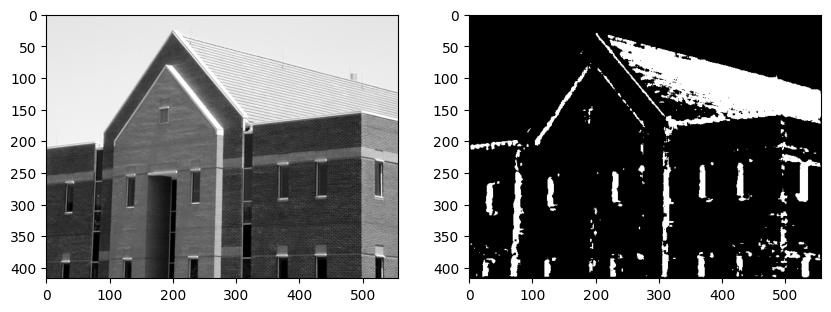

In [31]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(house, cmap='gray')
plt.subplot(1,2,2)
plt.imshow(crossing(laplacian, 50), cmap='gray')

## Algorytm Canny'ego

> Algorytm Canny'ego to często wykorzystywana metoda detekcji krawędzi.
> Zaproponowana została w 1986r. przez Johna F. Cannego.
> Przy jego projektowaniu założono trzy cele:
> - niska liczba błędów - algorytm powinien znajdywać wszystkie krawędzie oraz generować jak najmniej fałszywych detekcji,
> - punkty krawędziowe powinny być poprawnie lokalizowane - wykryte punkty powinny być jak najbardziej zbliżone do rzeczywistych,
> - krawędzie o szerokości 1 piksela - algorytm powinien zwrócić jeden punkt dla każdej rzeczywistej krawędzi.

Zaimplementuj algorytm detekcji krawędziCanny'ego:
1. W pierwszym kroku obraz przefiltruj dwuwymiarowym filtrem Gaussa.
2. Następnie oblicz gradient pionowy i poziomy ($g_x $ i $g_y$).
Jedną z metod jest filtracja Sobela.
3. Dalej oblicz amplitudę:
$M(x,y)  = \sqrt{g_x^2+g_y^2}$ oraz kąt:
$\alpha(x,y) = arctan(\frac{g_y}{g_x})$.
Do obliczenia kąta wykorzystaj funkcję `np.arctan2(x1, x2)`.
Wynik jest w radianach.
4. W kolejnym etapie wykonaj kwantyzację kątów gradientu.
Kąty od $-180^\circ$ do $180^\circ$ można podzielić na 8 przedziałów:
[$-22.5^\circ, 22.5^\circ$], [$22.5^\circ, 67.5^\circ$],
[$67.5^\circ, 112.5^\circ$], [$112.5^\circ, 157.5^\circ$],
[$157.5^\circ, -157.5^\circ$], [$-157.5^\circ, -112.5^\circ$],
[$-112.5^\circ, -67.5^\circ$], [$-67.5^\circ, -22.5^\circ$].
Przy czym należy rozpatrywać tylko 4 kierunki:
    - pionowy ($d_1$),
    - poziomy ($d_2$),
    - skośny lewy ($d_3$),
    - skośny prawy ($d_4$).
5. Dalej przeprowadź eliminację pikseli, które nie mają wartości maksymalnej (ang. *nonmaximal suppresion*).
Celem tej operacji jest redukcja szerokości krawędzi do rozmiaru 1 piksela.
Algorytm przebiega następująco.
W rozpatrywanym otoczeniu o rozmiarze $3 \times 3$:
    - określ do którego przedziału należy kierunek gradientu piksela centralnego ($d_1, d_2, d_3, d_4$).
    - przeanalizuje sąsiadów leżących na tym kierunku.
Jeśli choć jeden z nich ma amplitudę większą niż piksel centralny, to należy uznać, że nie jest lokalnym maksimum i do wyniku przypisać $g_N(x,y) = 0$.
W przeciwnym przypadku $g_N(x,y) = M(x,y)$.
Przez $g_N$ rozumiemy obraz detekcji lokalnych maksimów.
Zaimplementuj funkcję `nonmax`.
Pierwszym argementem jest macierz kierunków (po kwantyzacji).
Drugim argumentem jest macierz amplitudy.
6. Ostatnią operacją jest binaryzacja obrazu $g_N$.
Stosuje się tutaj tzw. binaryzację z histerezą.
Wykorzystuje się w niej dwa progi: $T_L$ i $T_H$, przy czym $T_L < T_H$.
Canny zaproponował, aby stosunek progu wyższego do niższego był jak 3 lub 2 do 1.
Rezultaty binaryzacji można opisać jako:<br>
$g_{NH}(x,y) = g_N(x,y) \geq TH $<br>
$g_{NL}(x,y) = TH > g_N(x,y) \geq TL $<br>
Można powiedzieć, że na obrazie $g_{NH}$ są "pewne" krawędzie.
Natomiast na $g_{NL}$ "potencjalne".
Często krawędzie "pewne" nie są ciągłe.
Dlatego wykorzystuje się obraz $g_{NL}$ w następującej procedurze:
    - Stwórz stos zawierający wszystkie piksele zaznaczone na obrazie $g_{NH}$.
W tym celu wykorzystaj listę współrzędnych `[row, col]`.
Do pobrania elementu z początku służy metoda `list.pop()`.
Do dodania elementu na koniec listy służy metoda `list.append(new)`.
    - Stwórz obraz, który będzie zawierał informację czy dany piksel został już odwiedzony.
    - Stwórz obraz, któy zawierać będzie wynikowe krawędzie.
Jej rozmiar jest równy rozmiarowi obrazu.
    - Wykonaj pętlę, która będzie pobierać elementy z listy, dopóki ta nie będzie pusta.
W tym celu najlepiej sprawdzi się pętla `while`.
    - W każdej iteracji pobierz element ze stosu.
    - Sprawdź czy dany element został już odwiedzony.
    - Jeśli nie został, to:
        - Oznacz go jako odwiedzony,
        - Oznacz piksel jako krawędź w wyniku,
        - Sprawdź otoczenie piksela w obrazie $g_{NL}$,
        - Dodaj do stosu współrzędne otoczenia, które zawierają krawędź (potencjalną).
        Można to wykoanać np. pętlą po stworzonym otoczeniu.
7. Wyświetl obraz oryginalny, obraz $g_{NH}$ oraz obraz wynikowy.

Pomocnicze obrazy $g_{NH}$ i $g_{NL}$ zostały wprowadzone dla uproszczenia opisu.
Algorytm można zaimplementować wbardziej "zwarty" sposób.

Na podstawie powyższego opisu zaimplementuj algorytm Cannego.

(np.float64(-0.5), np.float64(556.5), np.float64(416.5), np.float64(-0.5))

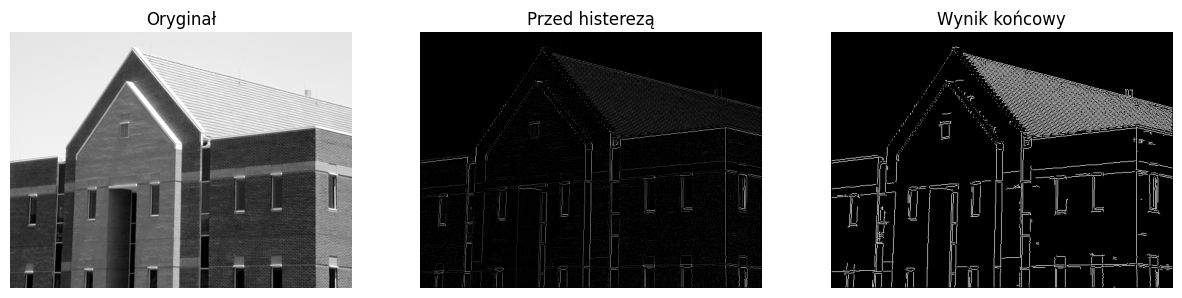

In [92]:
def nomax(alpha, magnitude):
  rows, cols = magnitude.shape
  result = np.zeros((rows, cols), dtype=np.float32)

  # zamiana na stopnie dla łatwiejszego obliczania
  alpha_deg = alpha * 180 / np.pi
  # pozbycie się ujemnych kątów
  alpha_deg[alpha_deg < 0] += 180

  for i in range(1, rows-1):
    for j in range(1, cols-1):
      #sąsiedzi
      q=255
      r=255

      # Kierunek poziomy (-)
      if(0 <= alpha_deg[i,j] < 22.5) or (157.5 <= alpha_deg[i,j] <= 180):
        q = magnitude[i, j+1]
        r = magnitude[i, j-1]
      # Kierynek skośny (/)
      elif(22.5 <= alpha_deg[i,j] < 67.5):
        q = magnitude[i+1, j-1]
        r = magnitude[i-1, j+1]
      # Kierunek pionowy (|)
      elif(67.5 <= alpha_deg[i,j] < 112.5):
        q = magnitude[i+1, j]
        r = magnitude[i-1, j]
      #Kierunek skośny (\)
      elif(112.5 <= alpha_deg[i,j] < 157.5):
        q = magnitude[i-1, j-1]
        r = magnitude[i+1, j+1]

      #jeśli jest maksimum wśród sąsiadów
      if(magnitude[i,j] >= q) and (magnitude[i,j] >= r):
        result[i,j] = magnitude[i,j]
      else: # jeśli nie jest maksimum to go zerujemy
        result[i,j] = 0

  return result


def histerize(img, weak, strong=255):
  rows, cols = img.shape
  result = np.zeros_like(img, dtype=np.uint8)

  stack = []

  for i in range(1, rows-1):
    for j in range(1, cols-1):
      if(img[i,j] == strong):
        result[i,j] = 255
        stack.append((i,j))

  #dopóki nie jest pusty
  while(stack):
    y,x = stack.pop()

    #sprawdzamy sąsiedztwo
    for i in range(y-1, y+2):
      for j in range(x-1, x+2):
        if(img[i,j] == weak and result[i,j]==0):
          result[i,j] = 255 #silna krawedź
          stack.append((i,j))

  return result


def canny_algotithm(img, gauss_window=3, gauss_sigma=0, tl_ratio = 0.4, th_ratio=0.8):
  img_filtered = cv2.GaussianBlur(img, (gauss_window, gauss_window), gauss_sigma)
  gx = cv2.Sobel(img_filtered, cv2.CV_64F, 1, 0, ksize=3)
  gy = cv2.Sobel(img_filtered, cv2.CV_64F, 0, 1, ksize=3)

  magnitude = np.sqrt(gx**2 + gy**2)
  alpha = np.arctan2(gy, gx)

  gn = nomax(alpha, magnitude)

  max_val = np.max(gn)
  TH = max_val * th_ratio
  TL = TH * tl_ratio


  res_thresh = np.zeros_like(gn, dtype=np.uint8)

  #255 - pewna krawędź, 50 - słaba krawędź, 0 - brak krawędzi
  weak_val = 50
  strong_val = 255

  strong_i, strong_j = np.where(gn >= TH)
  weak_i, weak_j = np.where((gn <= TH) & (gn >= TL));

  res_thresh[strong_i, strong_j] = strong_val
  res_thresh[weak_i, weak_j] = weak_val

  #histereza
  final_img = histerize(res_thresh, weak_val, strong_val)

  return gn, final_img


gn, canny_result = canny_algotithm(house, gauss_window=3, gauss_sigma=0, tl_ratio=0.3, th_ratio=0.15)

plt.figure(figsize=(15,10))

plt.subplot(1,3,1)
plt.title("Oryginał")
plt.imshow(house, cmap='gray')
plt.axis("off")

plt.subplot(1,3,2)
plt.title("Przed histerezą")
plt.imshow(gn, cmap='gray')
plt.axis("off")

plt.subplot(1,3,3)
plt.title("Wynik końcowy")
plt.imshow(canny_result, cmap='gray')
plt.axis("off")

## Algorytm Canny'ego - OpenCV

1. Wykonaj dektekcję krawędzi metodą Canny'ego wykorzystując funkcję `cv2.Canny`.
    - Pierwszym argumentem funkcji jest obraz wejściowy.
    - Drugim argumentem jest mniejszy próg.
    - Trzecim argumentem jest większy próg.
    - Czwarty argument to tablica, do której wpisany zostanie wynik.
    Można zwrócić go przez wartość i podać wartość `None`.
    - Piąty argument to rozmiar operatora Sobela (w naszym przypadku 3).
    - Szósty argument to rodzaj używanej normy.
    0 oznacza normę $L_1$, 1 oznacza normę $L_2$. Użyj $L_2$.
2. Wynik wyświetl i porównaj z własną implementacją.

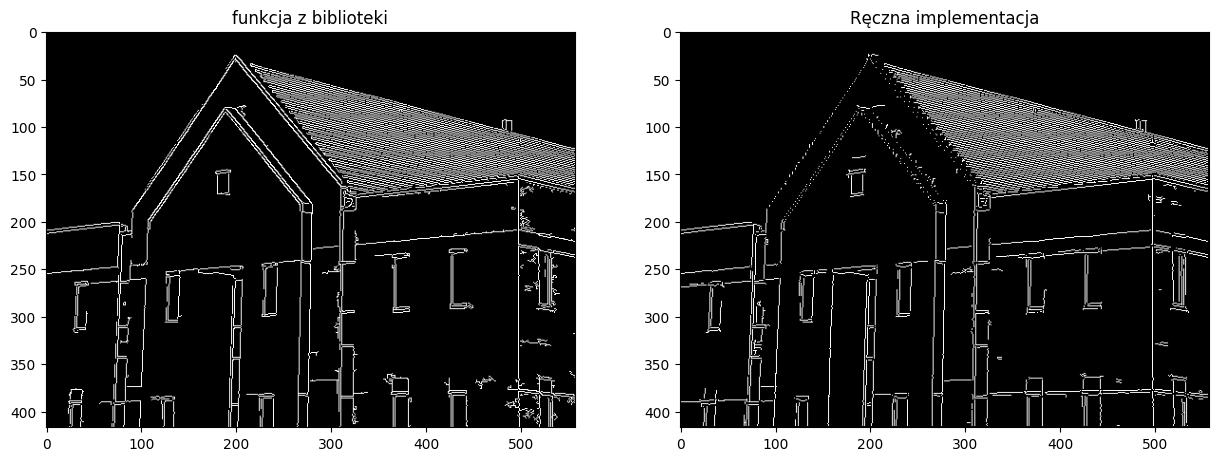

In [93]:
library_canny = cv2.Canny(house, 80, 190, apertureSize=3, L2gradient=True)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.title("funkcja z biblioteki")
plt.imshow(library_canny, cmap='gray')

plt.subplot(1,2,2)
plt.title("Ręczna implementacja")
plt.imshow(canny_result, cmap='gray')